In [ ]:
# This notebook contains the pre-processing pipeline of data of a single subject (S2) into a 
# model-ready data

# We are converting the labels to a binary classes and applying physiologically motivated filtering
# followed by normalization and sliding window segmentation

# The purpose of this notebook is to verify and show how this pipeline works before scaling it to 
# all subjects

In [ ]:
import pickle    
import numpy as np
import matplotlib.pyplot as plt 
import os 

from scipy.signal import butter, sosfiltfilt, savgol_filter

In [ ]:
subject_path = "../data/raw/S2/S2.pkl"

with open(subject_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print(data.keys())

dict_keys(['signal', 'label', 'subject'])


In [ ]:
print("Subject ID:", data["subject"])   
print("Label shape:", data["label"].shape)  
print("Signal keys:", data["signal"].keys())

Subject ID: S2
Label shape: (4255300,)
Signal keys: dict_keys(['chest', 'wrist'])


In [ ]:
print(data["signal"].keys())

dict_keys(['chest', 'wrist'])


In [ ]:
print(data["signal"]["chest"].keys())

dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])


In [ ]:
chest = data["signal"]["chest"]

ecg = chest["ECG"].flatten()
eda = chest["EDA"].flatten()
resp = chest["Resp"].flatten()
temp = chest["Temp"].flatten()

labels = data["label"]

print("ECG:", ecg.shape)
print("EDA:", eda.shape)
print("Resp:", resp.shape)
print("Temp:", temp.shape)
print("Labels:", labels.shape)

ECG: (4255300,)
EDA: (4255300,)
Resp: (4255300,)
Temp: (4255300,)
Labels: (4255300,)


In [ ]:
#According to the official dataset documentation:
#- 0 → transient / undefined
#- 1 → baseline
#- 2 → stress (TSST)
#- 3 → amusement
#- 4 → meditation
#- 5–7 → ignore

In [ ]:
unique_labels, counts = np.unique(labels, return_counts=True)

print("Label | Count | Seconds | Minutes")
print("-" * 45)
for lbl, cnt in zip(unique_labels, counts):
    secs = cnt / 700
    mins = secs / 60
    print(f"  {lbl}   | {cnt:7d} | {secs:7.1f}s  | {mins:5.1f} min")

Label | Count | Seconds | Minutes
---------------------------------------------
  0   | 2142701 |  3061.0s  |  51.0 min
  1   |  800800 |  1144.0s  |  19.1 min
  2   |  430500 |   615.0s  |  10.2 min
  3   |  253400 |   362.0s  |   6.0 min
  4   |  537599 |   768.0s  |  12.8 min
  6   |   45500 |    65.0s  |   1.1 min
  7   |   44800 |    64.0s  |   1.1 min


In [ ]:
#Only the following conditions are retained:
#- Baseline (label 1)
#- Stress (label 2)
#- Amusement (label 3)

In [ ]:
mask = np.isin(labels, [1, 2, 3])

ecg    = ecg[mask]
eda    = eda[mask]
resp   = resp[mask]
temp   = temp[mask]
labels = labels[mask]

print("Samples after masking:", len(labels))

print("Unique labels after mask:", np.unique(labels))

Samples after masking: 1484700
Unique labels after mask: [1 2 3]


In [ ]:
#Stress(label 2) is mapped to Class 1 while the Baseline(label 1) and amusement(label 3) 
# are grouped into Class 0 

In [ ]:
labels = np.where(labels == 2, 1, 0)

unique, counts = np.unique(labels, return_counts=True)
print("Binary label distribution:")
for u, c in zip(unique, counts):
    name = "stress" if u == 1 else "non-stress"
    print(f"  Class {u} ({name}): {c} samples  ({c/len(labels)*100:.1f}%)")

Binary label distribution:
  Class 0 (non-stress): 1054200 samples  (71.0%)
  Class 1 (stress): 430500 samples  (29.0%)


In [ ]:
fs = 700   

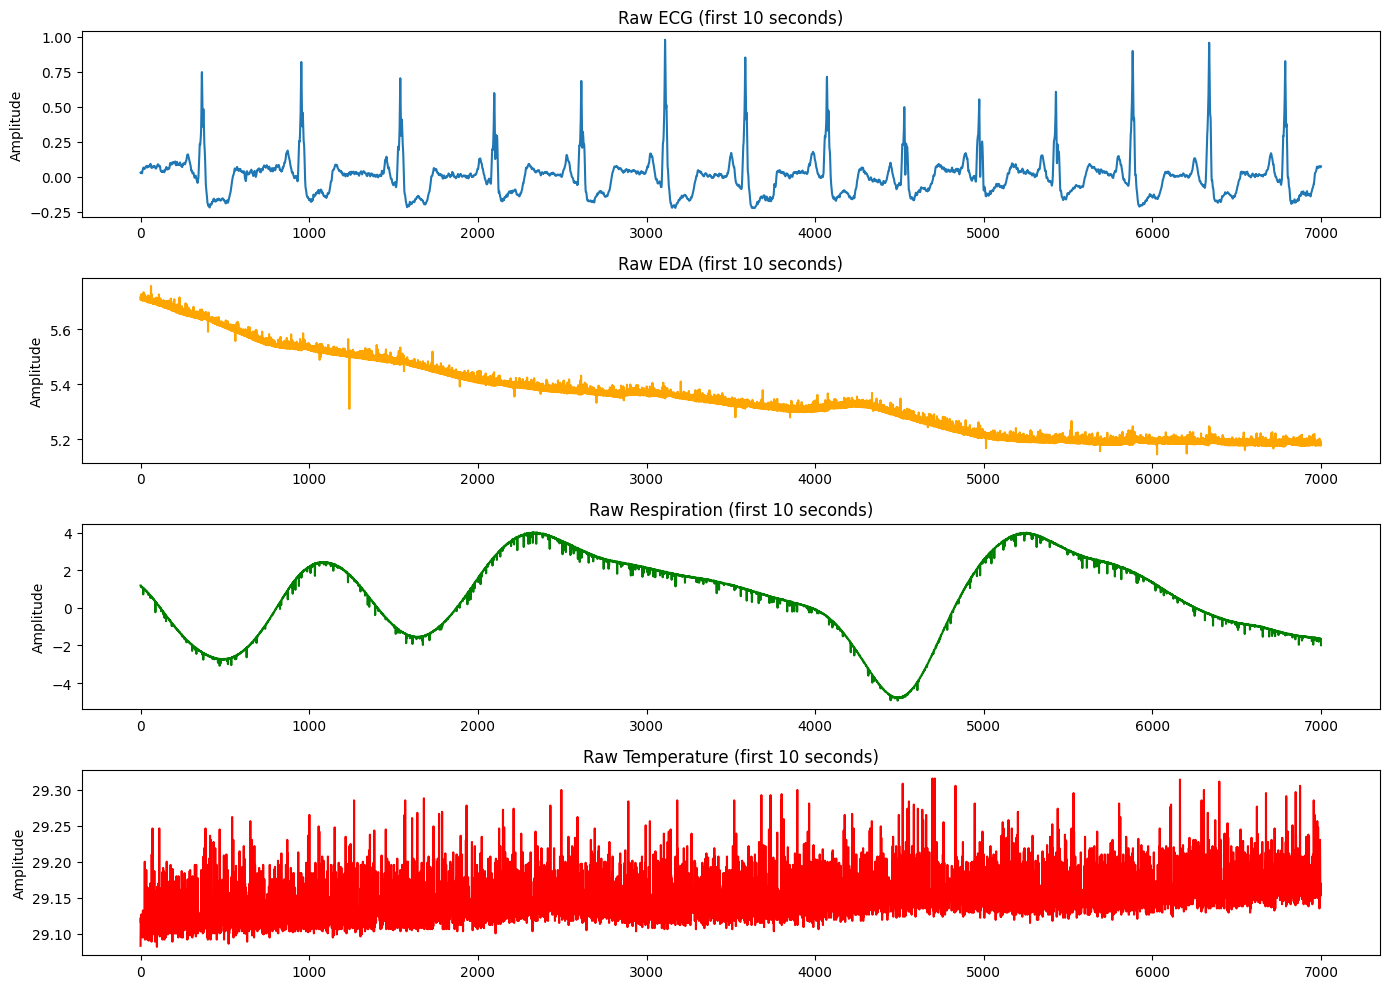

In [ ]:
plot_len = 10 * fs

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(ecg[:plot_len])
axes[0].set_title("Raw ECG (first 10 seconds)")
axes[0].set_ylabel("Amplitude")

axes[1].plot(eda[:plot_len], color="orange")
axes[1].set_title("Raw EDA (first 10 seconds)")
axes[1].set_ylabel("Amplitude")

axes[2].plot(resp[:plot_len], color="green")
axes[2].set_title("Raw Respiration (first 10 seconds)")
axes[2].set_ylabel("Amplitude")

axes[3].plot(temp[:plot_len], color="red")
axes[3].set_title("Raw Temperature (first 10 seconds)")
axes[3].set_ylabel("Amplitude")

plt.tight_layout()
plt.savefig("../data/processed/S2_raw_signals.png", dpi=100)
plt.show()

In [ ]:
#Raw physiological recordings contain noise, baseline drift, and motion artifacts.

#Filtering strategy:

#- ECG: 0.5–40 Hz Butterworth bandpass filter
#- EDA: 0.05–5 Hz Butterworth bandpass filter
#- Respiration: 0.05–1 Hz Butterworth bandpass filter
#- Temperature: Savitzky–Golay smoothing

In [ ]:
def bandpass(signal, low, high, fs, order=4):
    nyquist = fs / 2                   
    low_norm  = low  / nyquist       
    high_norm = high / nyquist

    sos = butter(order, [low_norm, high_norm], btype="band", output="sos")

    return sosfiltfilt(sos, signal)

In [ ]:
ecg_filtered = bandpass(ecg, low=0.5, high=40.0, fs=fs)

eda_filtered = bandpass(eda, low=0.05, high=5.0, fs=fs)

resp_filtered = bandpass(resp, low=0.05, high=1.0, fs=fs)

temp_filtered = savgol_filter(
    temp,
    window_length=701,   
    polyorder=2        
)

print("Filtering complete. Verification:")
for name, sig in [("ECG",  ecg_filtered), ("EDA",  eda_filtered),
                  ("Resp", resp_filtered), ("Temp", temp_filtered)]:
    print(f"  {name}: shape={sig.shape}  NaNs={int(np.isnan(sig).sum())}  Infs={int(np.isinf(sig).sum())}  std={sig.std():.4f}")

Filtering complete. Verification:
  ECG: shape=(1484700,)  NaNs=0  Infs=0  std=0.1359
  EDA: shape=(1484700,)  NaNs=0  Infs=0  std=0.0522
  Resp: shape=(1484700,)  NaNs=0  Infs=0  std=2.4441
  Temp: shape=(1484700,)  NaNs=0  Infs=0  std=1.6588


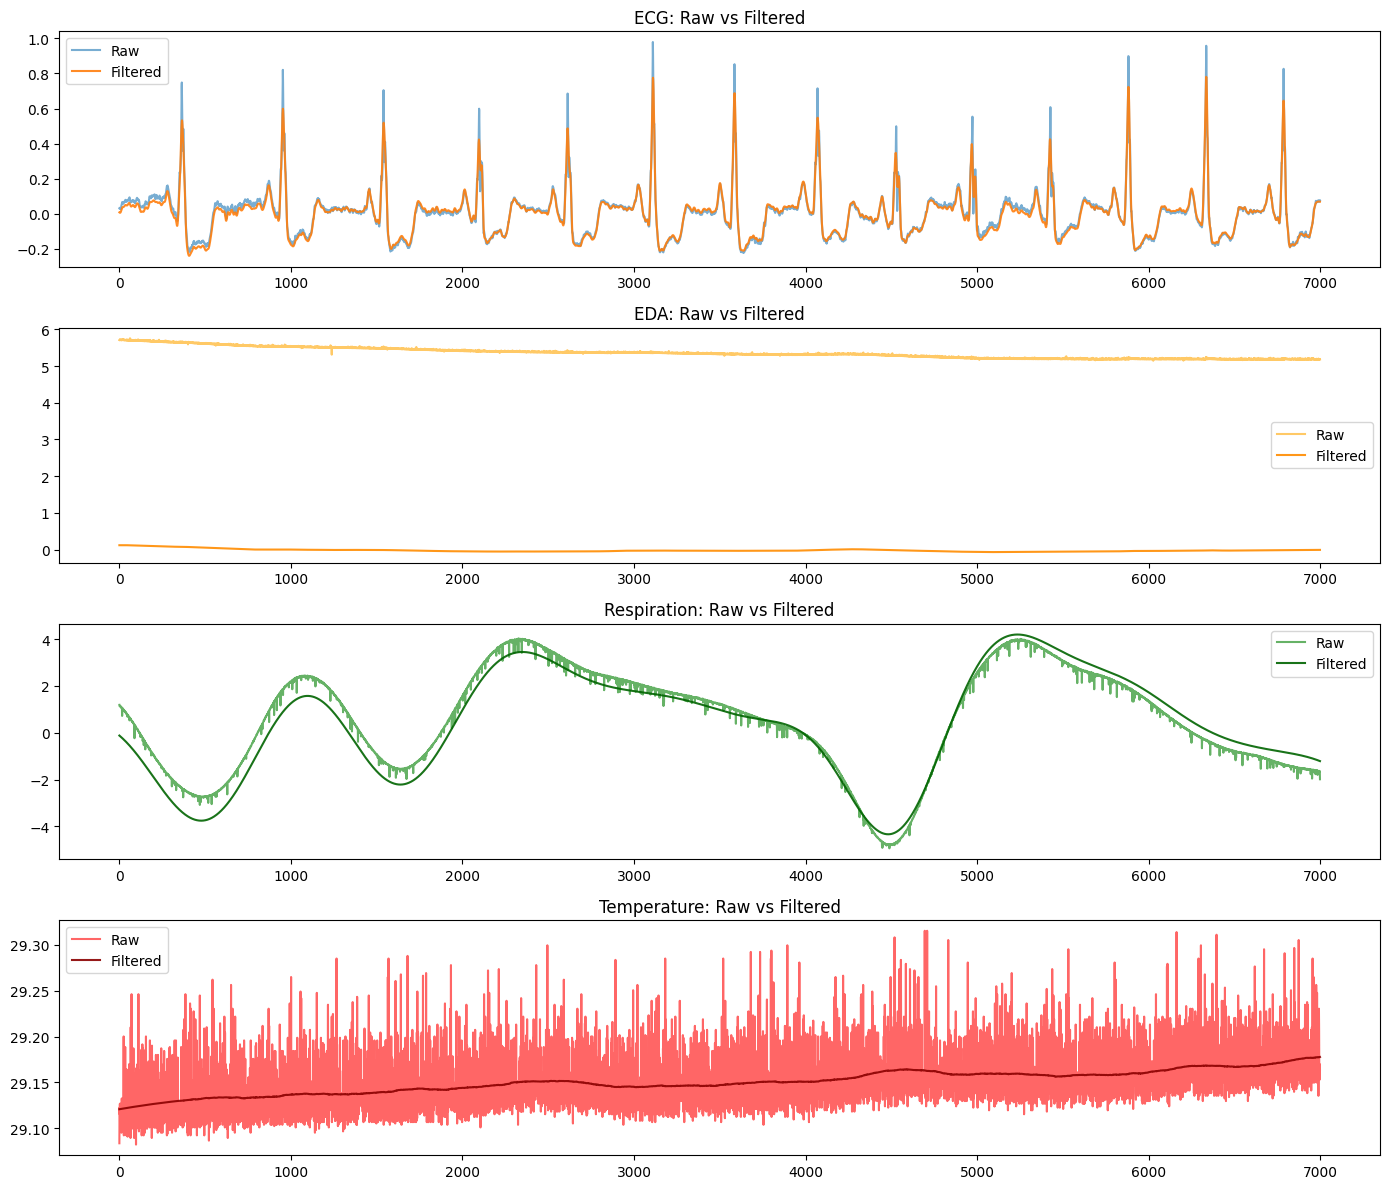

In [ ]:
plot_len = 10 * fs    # 10 seconds

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

axes[0].plot(ecg[:plot_len],          label="Raw",      alpha=0.6)
axes[0].plot(ecg_filtered[:plot_len], label="Filtered", alpha=0.9)
axes[0].set_title("ECG: Raw vs Filtered")
axes[0].legend()

axes[1].plot(eda[:plot_len],          label="Raw",      alpha=0.6, color="orange")
axes[1].plot(eda_filtered[:plot_len], label="Filtered", alpha=0.9, color="darkorange")
axes[1].set_title("EDA: Raw vs Filtered")
axes[1].legend()

axes[2].plot(resp[:plot_len],          label="Raw",      alpha=0.6, color="green")
axes[2].plot(resp_filtered[:plot_len], label="Filtered", alpha=0.9, color="darkgreen")
axes[2].set_title("Respiration: Raw vs Filtered")
axes[2].legend()

axes[3].plot(temp[:plot_len],          label="Raw",      alpha=0.6, color="red")
axes[3].plot(temp_filtered[:plot_len], label="Filtered", alpha=0.9, color="darkred")
axes[3].set_title("Temperature: Raw vs Filtered")
axes[3].legend()

plt.tight_layout()
plt.savefig("../data/processed/S2_filtered_comparison.png", dpi=100)
plt.show()

In [ ]:
#Signal Normalization

In [ ]:
def zscore(signal):
    mean = np.mean(signal)
    std  = np.std(signal)
    return (signal - mean) / (std + 1e-8)

ecg_norm  = zscore(ecg_filtered)
eda_norm  = zscore(eda_filtered)
resp_norm = zscore(resp_filtered)
temp_norm = zscore(temp_filtered)

print("ECG  — mean: {:.4f}  std: {:.4f}".format(np.mean(ecg_norm),  np.std(ecg_norm)))
print("EDA  — mean: {:.4f}  std: {:.4f}".format(np.mean(eda_norm),  np.std(eda_norm)))
print("Resp — mean: {:.4f}  std: {:.4f}".format(np.mean(resp_norm), np.std(resp_norm)))
print("Temp — mean: {:.4f}  std: {:.4f}".format(np.mean(temp_norm), np.std(temp_norm)))

ECG  — mean: 0.0000  std: 1.0000
EDA  — mean: 0.0000  std: 1.0000
Resp — mean: -0.0000  std: 1.0000
Temp — mean: 0.0000  std: 1.0000


In [ ]:
window_size = 30 * fs    
stride      = 15 * fs    

print("Window size:", window_size, "samples =", window_size/fs, "seconds")
print("Stride:     ", stride,      "samples =", stride/fs,      "seconds")
print()

n_possible = (len(labels) - window_size) // stride
print("Estimated number of windows:", n_possible)

Window size: 21000 samples = 30.0 seconds
Stride:      10500 samples = 15.0 seconds

Estimated number of windows: 139


In [ ]:
#Sliding Window Segmentation

#Continuous readings are segmented into fixed-length windows to generate model inputs.

In [ ]:
X = []    
y = []    

for start in range(0, len(labels) - window_size, stride):
    end = start + window_size    

    # Stack all 4 modalities as rows → shape (4, 21000)
    sample = np.stack([
        ecg_norm[start:end],     
        eda_norm[start:end],    
        resp_norm[start:end],    
        temp_norm[start:end]    
    ])

    window_label = np.bincount(labels[start:end]).argmax()

    X.append(sample)
    y.append(window_label)

print("Windowing complete.")
print("Number of windows created:", len(X))

Windowing complete.
Number of windows created: 140


In [ ]:
X = np.array(X, dtype=np.float32) 
y = np.array(y, dtype=np.int64)    

print("X shape:", X.shape)   
print("y shape:", y.shape)    
print()
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

X shape: (140, 4, 21000)
y shape: (140,)

X dtype: float32
y dtype: int64


In [20]:
unique, counts = np.unique(y, return_counts=True)

print("Class balance in windowed data:")
for u, c in zip(unique, counts):
    name = "stress" if u == 1 else "non-stress"
    print(f"  Class {u} ({name}): {c} windows  ({c/len(y)*100:.1f}%)")

Class balance in windowed data:
  Class 0 (non-stress): 99 windows  (70.7%)
  Class 1 (stress): 41 windows  (29.3%)


In [21]:
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()

print("NaN values in X:", nan_count)
print("Inf values in X:", inf_count)

NaN values in X: 0
Inf values in X: 0


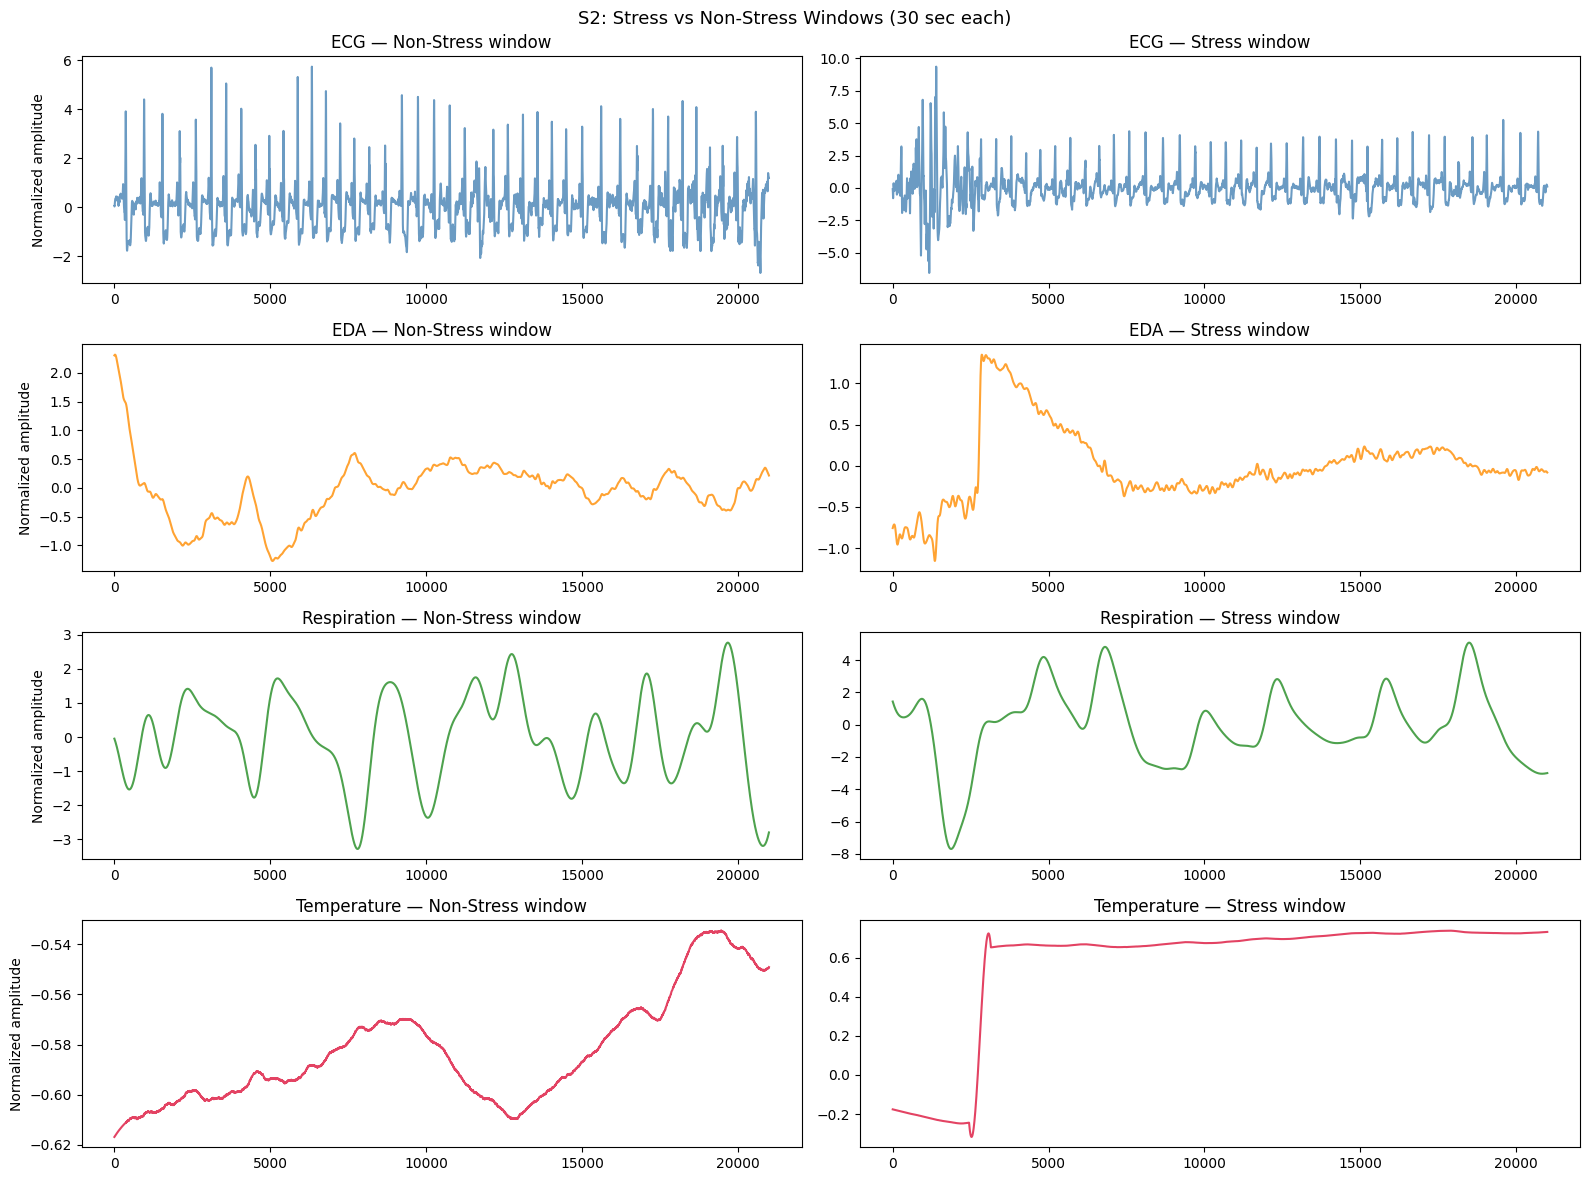

In [ ]:
stress_idx     = np.where(y == 1)[0][0]     
nonstress_idx  = np.where(y == 0)[0][0]     

modality_names = ["ECG", "EDA", "Respiration", "Temperature"]
colors         = ["steelblue", "darkorange", "forestgreen", "crimson"]

fig, axes = plt.subplots(4, 2, figsize=(16, 12))

for mod_idx in range(4):
    axes[mod_idx, 0].plot(
        X[nonstress_idx, mod_idx],
        color=colors[mod_idx], alpha=0.8
    )
    axes[mod_idx, 0].set_title(f"{modality_names[mod_idx]} — Non-Stress window")
    axes[mod_idx, 0].set_ylabel("Normalized amplitude")

    axes[mod_idx, 1].plot(
        X[stress_idx, mod_idx],
        color=colors[mod_idx], alpha=0.8
    )
    axes[mod_idx, 1].set_title(f"{modality_names[mod_idx]} — Stress window")

plt.suptitle("S2: Stress vs Non-Stress Windows (30 sec each)", fontsize=13)
plt.tight_layout()
plt.savefig("../data/processed/S2_window_comparison.png", dpi=100)
plt.show()

In [ ]:
print("X value statistics:")
print(f"  Min:  {X.min():.4f}")
print(f"  Max:  {X.max():.4f}")
print(f"  Mean: {X.mean():.4f}")
print(f"  Std:  {X.std():.4f}")
print()

for i, name in enumerate(["ECG", "EDA", "Resp", "Temp"]):
    ch = X[:, i, :]     
    print(f"{name} — min: {ch.min():.3f}  max: {ch.max():.3f}  mean: {ch.mean():.3f}  std: {ch.std():.3f}")

X value statistics:
  Min:  -24.5190
  Max:  24.9317
  Mean: -0.0017
  Std:  1.0004

ECG — min: -11.004  max: 10.669  mean: -0.000  std: 1.001
EDA — min: -24.519  max: 24.932  mean: 0.001  std: 1.004
Resp — min: -7.700  max: 7.975  mean: 0.001  std: 1.000
Temp — min: -1.193  max: 2.482  mean: -0.008  std: 0.996


In [ ]:
os.makedirs("../data/processed", exist_ok=True)

np.save("../data/processed/S2_X.npy", X)
np.save("../data/processed/S2_y.npy", y)

print("Saved:")
print("  ../data/processed/S2_X.npy  →  shape:", X.shape)
print("  ../data/processed/S2_y.npy  →  shape:", y.shape)

Saved:
  ../data/processed/S2_X.npy  →  shape: (140, 4, 21000)
  ../data/processed/S2_y.npy  →  shape: (140,)


In [ ]:
X_check = np.load("../data/processed/S2_X.npy")
y_check = np.load("../data/processed/S2_y.npy")

print("Reloaded X shape:", X_check.shape)
print("Reloaded y shape:", y_check.shape)
print("Arrays match:", np.allclose(X, X_check) and np.array_equal(y, y_check))

Reloaded X shape: (140, 4, 21000)
Reloaded y shape: (140,)
Arrays match: True


In [ ]:
stress_count     = (y == 1).sum()
nonstress_count  = (y == 0).sum()
total_windows    = len(y)
duration_minutes = (len(ecg) / fs) / 60 

print("=" * 50)
print("S2 PREPROCESSING SUMMARY")
print("=" * 50)
print(f"Total usable signal duration : {duration_minutes:.1f} minutes")
print(f"Total windows created        : {total_windows}")
print(f"  Stress windows (class 1)   : {stress_count}  ({stress_count/total_windows*100:.1f}%)")
print(f"  Non-stress windows (class 0): {nonstress_count}  ({nonstress_count/total_windows*100:.1f}%)")
print(f"X array shape                : {X.shape}")
print(f"y array shape                : {y.shape}")
print(f"NaN count                    : {np.isnan(X).sum()}")
print(f"Inf count                    : {np.isinf(X).sum()}")
print("=" * 50)
print("Files saved:")
print("  ../data/processed/S2_X.npy")
print("  ../data/processed/S2_y.npy")
print("=" * 50)

S2 PREPROCESSING SUMMARY
Total usable signal duration : 35.4 minutes
Total windows created        : 140
  Stress windows (class 1)   : 41  (29.3%)
  Non-stress windows (class 0): 99  (70.7%)
X array shape                : (140, 4, 21000)
y array shape                : (140,)
NaN count                    : 0
Inf count                    : 0
Files saved:
  ../data/processed/S2_X.npy
  ../data/processed/S2_y.npy
